<a href="https://colab.research.google.com/github/Xlbrian/sir_llm_hackathon_skeleton/blob/main/notebooks/sir_llm_hackathon_skeleton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 AI-Guided SIR Modeling Hackathon (2 Hours)

This notebook is the **workshop skeleton** for the **AI-Guided SIR Modeling Hackathon**.

- Dataset: **Niamey, Niger measles outbreaks** (biweekly case counts; communities A/B/C)
- Tooling: **Google Colab + Python + ChatGPT**
- Time unit: **biweeks**
- Key modeling shortcut: infectious period ≈ **2 weeks** ⇒ **γ ≈ 1 per biweek**

---

## How to use this notebook
Each section contains:
1) A **ChatGPT prompt** (Markdown) you can copy into ChatGPT  
2) A **starter code cell** (often with TODOs) to run in Colab

✅ **Rule of thumb:** Always request **plots + sanity checks** when you ask ChatGPT for help.


## 0. Setup

### ChatGPT Prompt (copy/paste)
```text
Persona:
You are an expert epidemiological modeler and Python educator.

Task:
- Write a Colab-ready setup cell: imports, basic plotting config, and a helper for reproducibility.
- If any package is missing show me how to run pip install

Constraints:
- Use numpy, scipy, pandas, matplotlib only

Verification:
- Print library versions and a simple "ready" message.
```


In [3]:
# ============================================================
# Epidemiological Modeling Setup Cell (Colab Ready)
# ============================================================

# ---- Install packages if missing ----
import importlib
import subprocess
import sys

required_packages = ["numpy","scipy","pandas","matplotlib"]

for pkg in required_packages:
  try:
    importlib.import_module(pkg)
  except ImportError:
    print(f"{pkg} not found. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# ---- Imports -----
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

# ---- Basic plotting configuration ----
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["font.family"] = "sans-serif"

# ---- Reproducibility helper ----
def set_seed(seed=42):
    """
    Set random seed for reproducible simulations.
    """
    np.random.seed(seed)
    print(f"Random seed set to {seed}")

# Set default seed
set_seed(42)

# ---- Print library versions ----
print("\nLibrary Versions")
print("----------------")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"SciPy: {scipy.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")

print("\nEnvironment ready for epidemiological modelling.")


Random seed set to 42

Library Versions
----------------
NumPy: 2.0.2
Pandas: 2.2.2
SciPy: 1.16.3
Matplotlib: 3.10.0

Environment ready for epidemiological modelling.


### Chat GPT Prompt to generate code to load data

```text
Persona:
You are an expert epidemiological modeler and Python educator.

Task:
- Write a Colab-ready python code to:
  - Create `data` folder if it is not exists
  - Download the csv file `https://github.com/merlinvn/ai-guided-modeling-hackathon/raw/refs/heads/main/data/niamey.csv` and put in the `data` folder.
```

In [4]:
import os
import requests

# 1. Create 'data' folder if it doesn't exist
data_dir = "data"
os.makedirs(data_dir, exist_ok=True)

# 2. Download the CSV file
url = "https://github.com/merlinvn/ai-guided-modeling-hackathon/raw/refs/heads/main/data/niamey.csv"
csv_path = os.path.join(data_dir, "niamey.csv")

# Fetch the file
response = requests.get(url)
if response.status_code == 200:
    with open(csv_path, "wb") as f:
        f.write(response.content)
    print(f"File downloaded successfully and saved to '{csv_path}'")
else:
    print(f"Failed to download file. Status code: {response.status_code}")

File downloaded successfully and saved to 'data/niamey.csv'


## 1. Explore the Niamey Measles Data:

### Load the dataset and compute basic statistics

#### ChatGPT Prompt (copy/paste)
```text
Persona:
You are an expert epidemiological modeler and Python educator.

Context:
- Dataset contains biweekly measles case counts from Niamey, Niger
- File path: data/niamey.csv

Task:
Write Python code to:
1. Load data/niamey.csv store it to `measles_df`
2. Display the first few rows
3. Print column names and basic information about the dataset
4. Show basic statistics about dataset

Constraints
- Use pandas only
- Keep code simple and readable

```

In [5]:
# 1. Load dataset
measles_df = pd.read_csv("data/niamey.csv")

# 2. Display first few rows
print("First few rows of the dataset:")
print(measles_df.head())

# 3. Print column names and basic dataset information
print("\nColumn names:")
print(measles_df.columns.tolist())

print("\nDataset information:")
print(measles_df.info())

# 4. Show basic statistics
print("\nBasic statistics:")
print(measles_df.describe())

First few rows of the dataset:
   biweek community  measles
0       1         A     22.0
1       2         A     27.0
2       3         A     64.0
3       4         A     84.0
4       5         A    116.0

Column names:
['biweek', 'community', 'measles']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   biweek     48 non-null     int64  
 1   community  48 non-null     object 
 2   measles    47 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.3+ KB
None

Basic statistics:
          biweek      measles
count  48.000000    47.000000
mean    8.500000   232.531915
std     4.658554   316.792200
min     1.000000     0.000000
25%     4.750000    13.500000
50%     8.500000    81.000000
75%    12.250000   251.500000
max    16.000000  1041.000000


### Exercise

// TODO: Participants write a prompt to explain the results in plain language


### Basic Plot

#### ChatGPT Prompt (copy/paste)
```text
Persona:
You are an expert epidemiological modeler and Python educator.

Context:
- Dataset is already loaded into a DataFrame called `measles_df`
- Columns: biweek, community, measles

Task:
- Plot measles cases over time for each community
- Use one time-series plot
- Label axes and include a legend
- Briefly explain what biweekly case counts mean for epidemic modeling

```

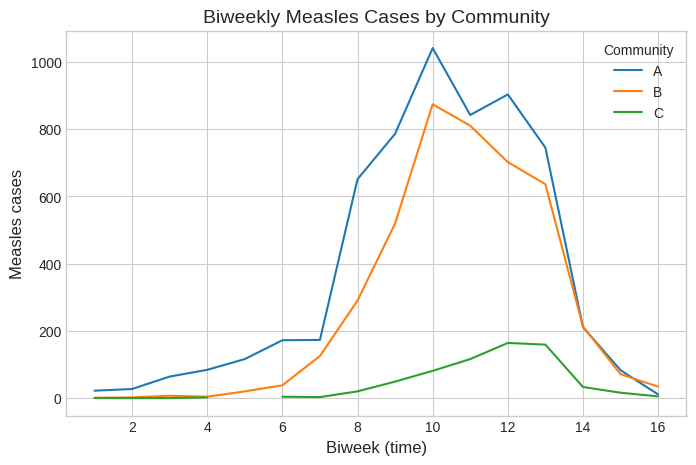

In [6]:
# Plot measles cases over time for each community
plt.figure()

for community, df in measles_df.groupby("community"):
    plt.plot(df["biweek"], df["measles"], label=community)

plt.xlabel("Biweek (time)")
plt.ylabel("Measles cases")
plt.title("Biweekly Measles Cases by Community")
plt.legend(title="Community")

plt.show()

In epidemic modeling the biweekly case counts mean the following:

**Time resolution** – Using biweekly counts makes trends easier to observe by smoothing out daily fluctuations while still capturing the dynamics of the outbreak.

**Epidemic growth** – Make it easy to see how cases rise and fall over time; for example, Community A peaks around biweek 10–12, indicating the outbreak's height.

**Comparing communities** – Differences in peak size and timing reflect how the epidemic spreads differently in each community. Community C has a smaller, later peak compared to A and B.

**Parameter estimation** – Biweekly data are often used to estimate model parameters like transmission rates, the reproductive number, or the effect of interventions.

## 2. Feature-Based Estimation: Early Growth (Quick R₀)

We estimate early exponential growth using a semi-log regression:
- Choose an early window where cases grow roughly exponentially.
- Fit `log(cases)` vs time.

### ChatGPT Prompt (copy/paste)
```text
## Persona

You are an **expert in infectious disease modeling**, with experience in early-outbreak analysis and interpretation of epidemic growth rates.

## Context

* **Disease:** Measles
* **Community:** A
* **Data:** Biweekly reported case counts
* **Epidemic phase:** Early outbreak (first ~8–10 biweeks), where case counts exhibit **exponential growth**
* **Dataset:** Already loaded as `measles_df`

### Dataset structure

Dataset Information:
`
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   biweek     48 non-null     int64  
 1   community  48 non-null     object
 2   measles    47 non-null     float64
dtypes: float64(1), int64(1), object(1)
`

## Task

Estimate the **early exponential growth rate** of the outbreak by:

1. Selecting an appropriate **early biweek window** (~ 8-10 biweeks)
2. Fitting a **log-linear model**: log(measles cases) vs. time
3. Producing a **semi-log plot** showing observed data and fitted exponential growth
4. Converting the estimated growth rate to an **approximate basic reproduction number (R₀)**, assuming:

   * Infectious removal rate: **gamma = 1 per biweek**

## Constraints

* Use **NumPy** and **SciPy** only (Matplotlib for plotting is acceptable)
* Clearly **state and explain modeling assumptions**
* Print key **statistical results** (e.g., slope, confidence intervals if available, R0)
* **Output code only** (do not execute)

## Verification / Expected Output

* A **semi-log plot** of measles cases with the fitted exponential curve
* Printed values for:

  * Estimated **growth rate (slope)**
  * Corresponding **R0 estimate**
```


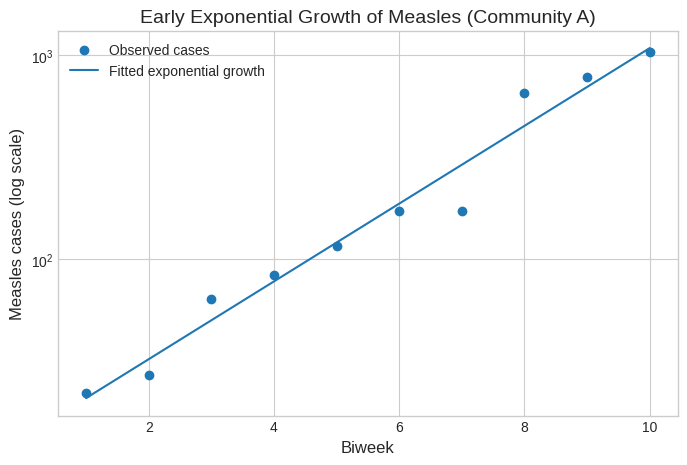

Estimated exponential growth rate (r): 0.4392081969042364
95% CI for growth rate: (np.float64(0.3837295672060551), np.float64(0.4946868266024177))
Approximate R0 estimate: 1.4392081969042363
R-squared: 0.9678417236700371

Modeling assumptions:
- Early outbreak phase approximates exponential growth.
- Population susceptibility is approximately constant.
- Reporting rate is constant over time.
- SIR relationship used: r = gamma * (R0 - 1).
- Infectious removal rate gamma assumed = 1 per biweek.


In [7]:
# -------------------------------
# 1. Select early outbreak window
# -------------------------------

# Filter to community A
community_a = measles_df[measles_df["community"] == "A"]

# Remove missing or zero values (log transform requires positive counts)
community_a = community_a[(community_a["measles"] > 0) & (~np.isnan(community_a["measles"]))]

# Select the first ~10 biweeks to represent early exponential growth
early_data = community_a.iloc[:10]

t = early_data["biweek"]
cases = early_data["measles"]

log_cases = np.log(cases)

t = t.astype(float)
log_cases = log_cases.astype(float)

# ---------------------------------------
# 2. Fit log-linear model: log(cases) ~ t
# ---------------------------------------
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(t, log_cases)

# 95% confidence interval for slope
z = 1.96
slope_ci_lower = slope - z * std_err
slope_ci_upper = slope + z * std_err

# ---------------------------------------
# 3. Convert growth rate to R0
# ---------------------------------------

# Assumption:
# Early outbreak approximates exponential growth in an SIR model
# r = gamma * (R0 - 1)
# therefore R0 = 1 + r / gamma

gamma = 1.0  # removal rate per biweek
R0 = 1 + slope / gamma

# ---------------------------------------
# 4. Generate fitted exponential curve
# ---------------------------------------

t_fit = np.linspace(t.min(), t.max(), 100)
log_fit = intercept + slope * t_fit
cases_fit = np.exp(log_fit)

# ---------------------------------------
# 5. Plot (semi-log)
# ---------------------------------------

plt.figure()

# Observed data
plt.scatter(t, cases, label="Observed cases")

# Fitted exponential growth
plt.plot(t_fit, cases_fit, label="Fitted exponential growth")

plt.yscale("log")
plt.xlabel("Biweek")
plt.ylabel("Measles cases (log scale)")
plt.title("Early Exponential Growth of Measles (Community A)")
plt.legend()

plt.show()

# ---------------------------------------
# 6. Print results
# ---------------------------------------

print("Estimated exponential growth rate (r):", slope)
print("95% CI for growth rate:", (slope_ci_lower, slope_ci_upper))
print("Approximate R0 estimate:", R0)
print("R-squared:", r_value**2)

# ---------------------------------------
# Modeling assumptions
# ---------------------------------------

print("\nModeling assumptions:")
print("- Early outbreak phase approximates exponential growth.")
print("- Population susceptibility is approximately constant.")
print("- Reporting rate is constant over time.")
print("- SIR relationship used: r = gamma * (R0 - 1).")
print("- Infectious removal rate gamma assumed = 1 per biweek.")

**Goal**
Assess how sensitive the estimated basic reproduction number (**R₀**) is to the choice of early-outbreak window length.

**Method (brief)**
For a sequence of increasing early-outbreak windows (measured in biweeks):

* Fit a log-linear model to early reported measles cases to estimate the exponential growth rate.
* Convert the growth rate to **R₀** assuming a fixed infectious removal rate (γ = 1 per biweek).
* Compute a 95% confidence interval for **R₀** from the regression uncertainty.
* Visualize **R₀** and its uncertainty as a function of the window length.

**Interpretation**
Stable **R₀** estimates across window lengths suggest a robust early-growth signal, while strong variation indicates sensitivity to window choice or departures from exponential growth.

---

### Continue with the this prompt

```text
For a range of early-outbreak window lengths, plot the estimated R0 (derived from exponential growth rates) together with its 95% confidence interval, as a function of the initial period length (in biweeks).
```

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


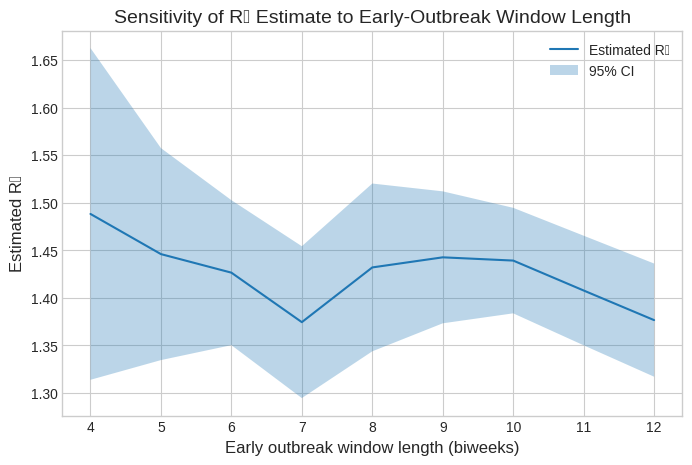

In [8]:
# ---------------------------------------
# Filter data for Community A
# ---------------------------------------

community_a = measles_df[measles_df["community"] == "A"]

# Remove missing or non-positive values (required for log transform)
community_a = community_a[(community_a["measles"] > 0) & (~np.isnan(community_a["measles"]))]

t_all = community_a["biweek"]
cases_all = community_a["measles"]

# ---------------------------------------
# Parameters
# ---------------------------------------

gamma = 1.0  # removal rate per biweek

# Range of early outbreak window lengths
min_window = 4
max_window = 12

window_lengths = []
R0_estimates = []
R0_lower = []
R0_upper = []

# ---------------------------------------
# Estimate growth rate for each window
# ---------------------------------------

for w in range(min_window, max_window + 1):

    t = t_all[:w]
    cases = cases_all[:w]

    log_cases = np.log(cases)

    slope, intercept, r_value, p_value, std_err = stats.linregress(t, log_cases)

    # 95% CI for slope
    z = 1.96
    slope_low = slope - z * std_err
    slope_high = slope + z * std_err

    # Convert to R0
    R0 = 1 + slope / gamma
    R0_low = 1 + slope_low / gamma
    R0_high = 1 + slope_high / gamma

    window_lengths.append(w)
    R0_estimates.append(R0)
    R0_lower.append(R0_low)
    R0_upper.append(R0_high)

# Convert to arrays
window_lengths = np.array(window_lengths)
R0_estimates = np.array(R0_estimates)
R0_lower = np.array(R0_lower)
R0_upper = np.array(R0_upper)

# ---------------------------------------
# Plot R0 estimates vs window length
# ---------------------------------------

plt.figure()

plt.plot(window_lengths, R0_estimates, label="Estimated R₀")

plt.fill_between(
    window_lengths,
    R0_lower,
    R0_upper,
    alpha=0.3,
    label="95% CI"
)

plt.xlabel("Early outbreak window length (biweeks)")
plt.ylabel("Estimated R₀")
plt.title("Sensitivity of R₀ Estimate to Early-Outbreak Window Length")
plt.legend()

plt.show()

Using the above results, ask yourself and ChatGPT the follow up questions:

- Which early window length gives the most stable estimate of R0?

- Why might very short windows (e.g., 4 biweeks) produce less reliable estimates?

- What happens if you extend the window too far into the epidemic?

- Ask ChatGPT to modify the code to compute the variance of the R0 estimate across window lengths and identify the most stable region.

Then later (homeworks):

- Does the growth rate differ between communities?

- Which community had the fastest outbreak growth?

- Are the R0 estimates consistent across communities?

- Ask ChatGPT to repeat the full analysis for communities A, B, and C and plot the estimated R0 curves on the same figure.

**Most stable window length**

The range of 9–10 biweeks gives the most stable estimate. The confidence interval is notably narrow there, and the point estimate (~1.44) is relatively flat across that stretch, suggesting the model is converging on a consistent value rather than responding to noise.

**Why short windows (e.g., 4 biweeks) are less reliable**

The 4-biweek estimate has the widest confidence interval in the plot, reflecting several compounding problems:

***Small case counts*** — early in an outbreak, cumulative infections are low, so stochastic noise dominates the signal

***Lack of a full generation*** — R₀ estimation depends on observing at least one complete transmission chain; 4 biweeks may not capture enough generations

***Surveillance lag*** — reporting delays, testing ramp-up, and case ascertainment are worst at the very start, so the data quality is lowest exactly when you're trying to fit

The result is high sensitivity to individual data points, which explains both the elevated point estimate (~1.49) and the huge spread to ~1.66 at the top of the CI

**What happens with overly long windows**

Extending the window too far into the epidemic introduces its own biases:

***Depletion of susceptibles*** — once a meaningful fraction of the population is infected or immune, exponential growth slows for reasons other than the intrinsic transmissibility, causing R₀ to be underestimated

***Behavioral changes*** — interventions, awareness, and behavior shifts accumulate over time, all of which suppress transmission and blur the baseline R₀ signal

You can see this in the plot: estimates drift slightly downward beyond ~10 biweeks, consistent with these dampening effects pulling the estimate toward a lower effective R

The sweet spot here is **roughly 8–10 biweeks** — enough data for stability, not so much that epidemic dynamics corrupt the early-growth signal.

Variance of R0 estimates across window lengths: 0.0009679447572347157
Standard deviation of R0 estimates: 0.031111810574679124

Most stable window region (lowest rolling variance):
Window lengths: [ 8  9 10]
Variance in this region: 1.9589415056956346e-05



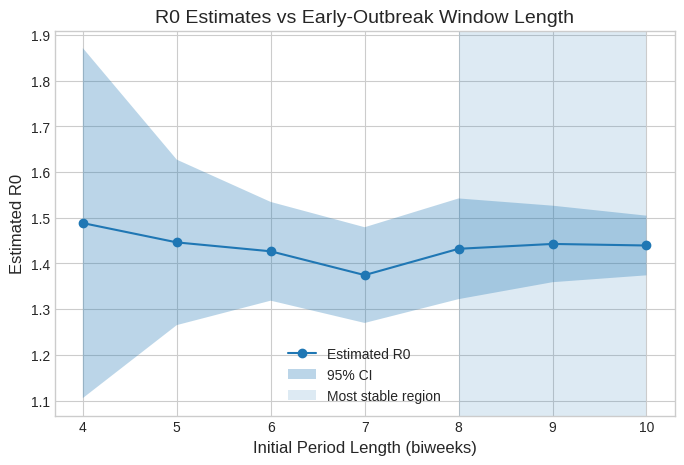

In [9]:
# -------------------------------------------------
# Modeling Assumptions
# -------------------------------------------------
# 1. Early outbreak dynamics follow exponential growth:
#       I(t) = I0 * exp(r * t)
# 2. Taking logs:
#       log(I(t)) = log(I0) + r * t
# 3. r is estimated from linear regression of log(cases) vs time
# 4. Relationship between r and R0 (early SIR approximation):
#       r ≈ gamma * (R0 - 1)
#       R0 ≈ 1 + r/gamma
# 5. Infectious removal rate:
#       gamma = 1 per biweek

gamma = 1.0

# -------------------------------------------------
# Prepare Data
# -------------------------------------------------
df = measles_df
df = df[df["community"] == "A"]
df = df.dropna(subset=["measles"])

t_all = df["biweek"].values
cases_all = df["measles"].values

cases_all = np.where(cases_all <= 0, np.nan, cases_all)

# -------------------------------------------------
# Define Early Window Range
# -------------------------------------------------
window_lengths = np.arange(4, 11)  # 4–10 biweeks

R0_estimates = []
R0_lower = []
R0_upper = []

# -------------------------------------------------
# Estimate R0 for Each Window Length
# -------------------------------------------------
for w in window_lengths:

    t = t_all[:w]
    cases = cases_all[:w]

    valid = ~np.isnan(cases)
    t = t[valid]
    cases = cases[valid]

    log_cases = np.log(cases)

    slope, intercept, r_value, p_value, std_err = stats.linregress(t, log_cases)

    r = slope

    n = len(t)
    alpha = 0.05
    t_crit = stats.t.ppf(1 - alpha/2, df=n-2)

    r_lower = r - t_crit * std_err
    r_upper = r + t_crit * std_err

    R0 = 1 + r/gamma
    R0_l = 1 + r_lower/gamma
    R0_u = 1 + r_upper/gamma

    R0_estimates.append(R0)
    R0_lower.append(R0_l)
    R0_upper.append(R0_u)

R0_estimates = np.array(R0_estimates)
R0_lower = np.array(R0_lower)
R0_upper = np.array(R0_upper)

# -------------------------------------------------
# Compute Variance Across Window Lengths
# -------------------------------------------------
R0_variance = np.var(R0_estimates)
R0_std = np.std(R0_estimates)

print("Variance of R0 estimates across window lengths:", R0_variance)
print("Standard deviation of R0 estimates:", R0_std)
print()

# -------------------------------------------------
# Identify Most Stable Region (lowest local variance)
# -------------------------------------------------
# Use rolling variance across 3 consecutive window lengths

stable_window = 3
rolling_variance = []

for i in range(len(R0_estimates) - stable_window + 1):
    segment = R0_estimates[i:i+stable_window]
    rolling_variance.append(np.var(segment))

rolling_variance = np.array(rolling_variance)

min_index = np.argmin(rolling_variance)

stable_range = window_lengths[min_index:min_index+stable_window]

print("Most stable window region (lowest rolling variance):")
print("Window lengths:", stable_range)
print("Variance in this region:", rolling_variance[min_index])
print()

# -------------------------------------------------
# Plot R0 vs Window Length with Confidence Intervals
# -------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(window_lengths, R0_estimates, marker='o', label="Estimated R0")

plt.fill_between(
    window_lengths,
    R0_lower,
    R0_upper,
    alpha=0.3,
    label="95% CI"
)

# Highlight stable region
plt.axvspan(stable_range[0], stable_range[-1], alpha=0.15, label="Most stable region")

plt.xlabel("Initial Period Length (biweeks)")
plt.ylabel("Estimated R0")
plt.title("R0 Estimates vs Early-Outbreak Window Length")
plt.legend()
plt.grid(True)

plt.show()

Testing for all communities

/tmp/ipykernel_231/2087653933.py:60: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r_value, p_value, std_err = stats.linregress(t, log_cases)


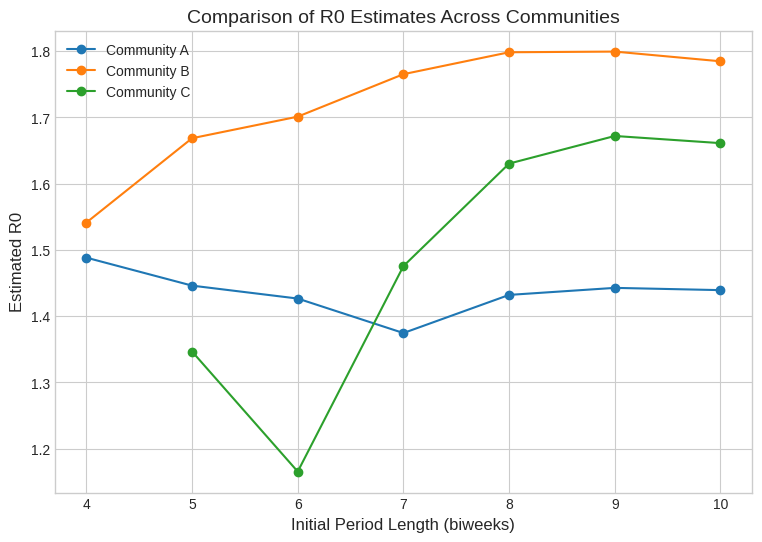

Community A
R0 estimates: [1.48823693 1.44600754 1.42649868 1.37445606 1.4320018  1.44261951
 1.4392082 ]
Variance of R0: 0.0009679447572347157
Most stable window region: [ 8  9 10]

Community B
R0 estimates: [1.54116461 1.66846117 1.70103058 1.76513005 1.79820792 1.79923193
 1.78458658]
Variance of R0: 0.007650740687540475
Most stable window region: [ 8  9 10]

Community C
R0 estimates: [       nan 1.34657359 1.16535769 1.47546697 1.63018637 1.67186997
 1.6610555 ]
Variance of R0: nan
Most stable window region: [4 5 6]



In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -------------------------------------------------
# Modeling Assumptions
# -------------------------------------------------
# 1. Early outbreak dynamics follow exponential growth:
#       I(t) = I0 * exp(r * t)
# 2. Taking logs gives:
#       log(I(t)) = log(I0) + r * t
# 3. r is estimated via linear regression of log(cases) vs time.
# 4. Early SIR approximation:
#       r ≈ gamma * (R0 - 1)
#       R0 ≈ 1 + r/gamma
# 5. Infectious removal rate:
#       gamma = 1 per biweek
# 6. Early exponential windows are explored to evaluate stability.

gamma = 1.0
communities = ["A", "B", "C"]
window_lengths = np.arange(4, 11)  # 4–10 biweeks

plt.figure(figsize=(9,6))

results = {}

# -------------------------------------------------
# Loop Through Communities
# -------------------------------------------------
for community in communities:

    df = measles_df.copy()
    df = df[df["community"] == community]
    df = df.dropna(subset=["measles"])

    t_all = df["biweek"].values
    cases_all = df["measles"].values

    cases_all = np.where(cases_all <= 0, np.nan, cases_all)

    R0_estimates = []
    R0_lower = []
    R0_upper = []

    # ---------------------------------------------
    # Loop Through Window Lengths
    # ---------------------------------------------
    for w in window_lengths:

        t = t_all[:w]
        cases = cases_all[:w]

        valid = ~np.isnan(cases)
        t = t[valid]
        cases = cases[valid]

        log_cases = np.log(cases)

        slope, intercept, r_value, p_value, std_err = stats.linregress(t, log_cases)

        r = slope

        n = len(t)
        alpha = 0.05
        t_crit = stats.t.ppf(1 - alpha/2, df=n-2)

        r_lower = r - t_crit * std_err
        r_upper = r + t_crit * std_err

        R0 = 1 + r/gamma
        R0_l = 1 + r_lower/gamma
        R0_u = 1 + r_upper/gamma

        R0_estimates.append(R0)
        R0_lower.append(R0_l)
        R0_upper.append(R0_u)

    R0_estimates = np.array(R0_estimates)
    R0_lower = np.array(R0_lower)
    R0_upper = np.array(R0_upper)

    # ---------------------------------------------
    # Compute Variance Across Windows
    # ---------------------------------------------
    variance = np.var(R0_estimates)
    std = np.std(R0_estimates)

    # Rolling variance to detect stable region
    stable_window = 3
    rolling_var = []

    for i in range(len(R0_estimates) - stable_window + 1):
        segment = R0_estimates[i:i+stable_window]
        rolling_var.append(np.var(segment))

    rolling_var = np.array(rolling_var)
    min_index = np.argmin(rolling_var)

    stable_range = window_lengths[min_index:min_index+stable_window]

    results[community] = {
        "R0": R0_estimates,
        "variance": variance,
        "stable_range": stable_range
    }

    # ---------------------------------------------
    # Plot R0 Curve
    # ---------------------------------------------
    plt.plot(window_lengths, R0_estimates, marker='o', label=f"Community {community}")

# -------------------------------------------------
# Plot Formatting
# -------------------------------------------------
plt.xlabel("Initial Period Length (biweeks)")
plt.ylabel("Estimated R0")
plt.title("Comparison of R0 Estimates Across Communities")
plt.legend()
plt.grid(True)

plt.show()

# -------------------------------------------------
# Print Summary Results
# -------------------------------------------------
for community in communities:

    print(f"Community {community}")
    print("R0 estimates:", results[community]["R0"])
    print("Variance of R0:", results[community]["variance"])
    print("Most stable window region:", results[community]["stable_range"])
    print()

## 3. Implement the SIR Model (Biweekly Units)

We use a **closed SIR** model for a single outbreak wave:
- S(t): susceptible
- I(t): infectious
- R(t): recovered

Time unit = **biweeks**.

### ChatGPT Prompt (copy/paste)
```text
Persona:
You are an expert epidemiological modeler and Python educator.

Context:
- Closed SIR model (no birth or death)
- Time unit: biweeks
- Infectious period is around 2 weeks (gamma is 1 per biweek)

Task:
Implement an SIR model using SciPy ODE solving:
- Define the SIR equations, the function name should be `sir_rhs`
- Solve over a biweekly time grid, put it in the function `simulate_sir`
- The initial parameters should include:
    - N: population size
    - I0: initial infections
    - immune_fration: fraction of population are immune
    - beta: transmission rate
    - gamma: recovery rate
- Plot S, I, R over time

Constraints:
- Use scipy.integrate.solve_ivp
- Keep code readable and commented

Verification:
- Plot S, I, R
- Verify S + I + R ~ N
```


Follow up Tasks:

- Run the model with different β values. (e.g.: 0.8, 1.0, 2.0, 3.0,...)

- When does the infection fail to grow?

- If the infectious period is 4 weeks, what should γ be?

- Change Initial Infections I0 (1 ,10, 100):
  - Does the peak size change?
  - Does the time to peak change?

- Change Population Size N (1000, 10000, 100000):
  - If you scale the population, does the shape of the epidemic curve change?

- Reproduction Number R0:
  - $R_0 = \frac{\beta}{\gamma}$

  - What happens when R₀ < 1?

  - What happens when R₀ > 1?

  - Try: beta = 0.5, 1.0, 1.5 with fixed gamma = 1

- Immunity & Vaccination:
  - Assume 20% of population is immune initially, how does herd immunity / vaccination affect the peak infection?

## 4. Map Model Output to Observations (Incidence via ΔH)

Observed data are **biweekly case counts**, not the state `I(t)`.  
We model **incidence** using an accumulator:

- Add `H(t)` with **dH/dt = β S I / N**  
- Predicted biweekly counts ≈ **ΔH** over each biweek interval

### ChatGPT Prompt (with the same chat session of the above SIR model chat or copy along the model code)

```text
Persona:
You are an expert epidemic modeler.

Context:
- Observed data are biweekly case counts (incidence) can be loaded as:

measles_df = pd.read_csv("data/niamey.csv")

dfA = (
    measles_df
    .loc[measles_df["community"] == "A", ["biweek", "measles"]]
    .dropna(subset=["measles"])
    .copy()
)


  - dfA["biweek"] contains the biweekly time index

  - dfA["measles"] contains observed biweekly incidence (number of cases)

- SIR model outputs states

Task:

Extend the SIR model by:
- Adding H(t) with dH/dt = beta*S*I/N
- Computing predicted biweekly cases as delta_H aligned to biweeks

Then:
- Plot observed measles incidence (dfA["measles"])

- Overlay simulated biweekly incidence (delta_H) on the same figure

- Use t[1:] when plotting delta_H as len(t) is different from len(delta_h) by 1 unit

Constraints:
- Keep code minimal and readable
- Return the full block code with comments to explain in details.

```


## 5. Fit Parameters by Least Squares

We fit parameters by minimizing squared error between observed counts and predicted ΔH.

Remember to edit the interface of the SIR model to match with the generated model in the previous step.

### ChatGPT Prompt (copy/paste)
```text
## Persona

You are an **expert in numerical optimization for epidemic models**, with experience fitting compartmental models to incidence data using nonlinear least squares.

---

## Data

We have **biweekly measles incidence data** for **Community A**:

measles_df = pd.read_csv("data/niamey.csv")

dfA = (
    measles_df
    .loc[measles_df["community"] == "A", ["biweek", "measles"]]
    .dropna(subset=["measles"])
    .copy()
)

* `dfA["biweek"]` → biweekly time index
* `dfA["measles"]` → observed biweekly incidence (case counts)

---

## Model

We use an SIR model that returns simulated incidence:


def simulate_sir(N, I0, immune_fraction, beta, gamma, t_max, dt=1):
    """
    Simulate SIR model on a biweekly time grid.

    Parameters
    ----------
    N : population size
    I0 : initial infections
    immune_fraction : fraction immune at start
    beta : transmission rate
    gamma : recovery rate (per biweek)
    t_max : duration of simulation (biweeks)
    dt : output step (biweeks)

    Returns
    -------
    t : time grid
    sol : solution object
    delta_H : predicted incidence per biweek
    """
---

## Objective

Fit model parameters to the observed incidence data using **nonlinear least squares**.

### Parameters to estimate:

* `N` (population size)
* `beta` (transmission rate)
* `I0` (initial infected)
* `immune_fraction` (Fraction immune at start)

### Fixed parameter:

* `gamma = 1.0`

---

## Initialization Strategy

Use an early-growth estimate:

* Estimated basic reproduction number:

  R_0 = 1.443

* Since ( R_0 = beta / gamma ), initialize beta_0 = 1.443

Choose reasonable initial guesses and bounds:

* `N` within plausible community size in range of (1000, 10000)
* `beta > 0` in the range of (1.0, 10.0)
* `I0 ≥ 1` in the range of (1,50)
* `immune_fraction` in the range of (0.1,0.4)

---

## Optimization Requirements

* Use `scipy.optimize.least_squares`
* Fit by minimizing SSE = (Observed - Predicted)^2
* Ensure runtime is suitable for a workshop (avoid heavy MCMC or expensive methods)

---

## Verification & Output

After fitting:

1. Overlay observed and fitted incidence curves
2. Print:

   * Best-fit parameter values
   * Sum of squared errors (SSE)

---

## Expected Deliverables

* Residual function definition
* Call to `least_squares`
* Overlay plot (observed vs fitted)
* Printed parameter estimates and SSE
* Clean, reproducible workshop-ready code
```


### Epidemiological Interpretation

- What is the estimated basic reproduction number? $R_0 = \frac{\beta}{\gamma}$
    - Is it reasonable for measles?

- What proportion of the population was initially susceptible?

- Does the fitted population size N seem realistic for the community?

- What fraction of the population gets infected during the epidemic? ${Attack Rate} = \frac{H_{final}}{N}$

### Things to explore later (optional)

- How sensitive are results to the initial guess? local vs global optima.

- Try different starting values for:

    - N

    - beta

    - I_0

    - immune_fraction

- Fix `N` and refit the model.

  - Does the fit improve or worsen?

- What happens if you fix immune_fraction and only fit β and I₀?

- Which parameter affects peak height the most?

- The effects of lower bounds and upper bounds

- Repeat the process for community B and C.

## Sensitivity of fixed beta on min SSE (optional)


Write a full detail prompt based on this is the basic prompt as your homework, code below just for example

```
generate code to see sensitivity of beta (from 0 to 10) on min SSE

```

## 6. Poisson Likelihood Inference (Counts)

For count data:
- $( y_t \sim \text{Poisson}(\mu_t) )$
- $( \mu_t = \rho \cdot \Delta H_t )$

where **ρ** is a reporting/ascertainment fraction.

### ChatGPT Prompt (copy/paste)
```text
# Persona

You are an **expert in numerical optimization for epidemic models**, with experience fitting compartmental models to incidence data using likelihood-based methods.

---

# Data

We have **biweekly measles incidence data** for **Community A**:

measles_df = pd.read_csv("data/niamey.csv")

dfA = (
    measles_df
    .loc[measles_df["community"] == "A", ["biweek", "measles"]]
    .dropna(subset=["measles"])
    .copy()
)

t_obs = dfA["biweek"].values
y_obs = dfA["measles"].values


* `t_obs` → biweekly time index
* `y_obs` → observed biweekly incidence (case counts)

---

# Model

We use an SIR model that returns simulated incidence:


def simulate_sir(N, I0, immune_fraction, beta, gamma, t_max, dt=1):
    """
    Simulate SIR model on a biweekly time grid.

    Parameters
    ----------
    N : population size
    I0 : initial infections
    immune_fraction : fraction immune at start
    beta : transmission rate
    gamma : recovery rate (per biweek)
    t_max : duration of simulation (biweeks)
    dt : output step (biweeks)

    Returns
    -------
    t : time grid
    sol : solution object
    delta_H : predicted incidence per biweek
    """

---

# Objective

Fit model parameters to the observed incidence data using **maximum likelihood under a Poisson observation model**.

Assume a Poisson observation model:

Y_t ~ Poisson(p * λ_t)

where:
- Y_t = observed incidence
- λ_t = model-predicted incidence (delta_H)
- p = reporting probability

---
Parameters to Estimate

N : population size  
beta : transmission rate  
I0 : initial infections  
immune_fraction : fraction immune at start

Observation parameter:

p : reporting probability

### Fixed parameter:

* `gamma = 1.0`

---

# Initialization Strategy

Use early-growth estimate: R_0 = 1.443

Since: R_0 = beta / gamma

Initialize: beta_0 = 1.443

Use reasonable bounds:

* `N` within plausible community size in range of (1000, 10000)
* `beta > 0` in the range of (1.0, 5.0)
* `I0 ≥ 1` in the range of (1,50)
* `immune_fraction` in the range of (0,0.4)
* p reporting probability in the range of (0.8,1.0)

---

# Optimization Requirements

Use `scipy.optimize.minimize` using Powell method.

Minimize the **negative Poisson log-likelihood**:

-log L(theta) = sum_t (p*lambda_t - y_t * log(p*lambda_t)

(omit constant log(y_t!) term)

- Add small epsilon to avoid `log(0)`.

- The SIR simulator may return incidence values that correspond to intervals between time points, producing len(delta_H) = len(t_sim) - 1 some code like this could help.

if len(delta_H) == len(t_sim) - 1:
        t_sim = t_sim[:-1]

- Ensure runtime is suitable for a workshop (no MCMC).

---

# Verification & Output

After fitting:

1. Overlay observed and fitted incidence curves
2. Print:

   * Best-fit parameter values
   * Final negative log-likelihood

---

# Expected Deliverables

* Negative log-likelihood function definition
* Call to optimizer
* Overlay plot (observed vs fitted incidence)
* Printed parameter estimates
* Clean, reproducible workshop-ready code
* Proper numerical safeguards (`epsilon` for stability)

```


## 7. Quick Uncertainty: Profile Likelihood for β (Optional)

### ChatGPT Prompt (copy/paste, continue with the likelihood chat)
```text
Persona:
You are an expert in likelihood-based inference.

Context:
- We already have a Poisson likelihood fit
- We want uncertainty for beta

Task:
Create a profile likelihood for beta:
1) Fix beta over a grid range (1.0, 5.0)
2) Optimize N, I0, immune_fraction, and p for each beta

* `N` within plausible community size range (1000, 10000)
* `I0 ≥ 1` (1,50)
* `immune_fraction` in the range of (0,0.4)
* p reporting probability in the range of (0.8,1.0)

3) Plot profile NLL(beta)

Constraints:
- Keep runtime reasonable for a workshop

Output:
- Profile plot
- Explain how to interpret the uncertainty
- Printed parameter estimates
- Single code block for Google Colab
```


## 8. Generate a Markdown Summary (Optional)

Participants are encouraged to modify these sample prompts to align with their preferences.


### Prompt 1 - Full report
```text
Persona

You are an expert epidemiologist, infectious disease modeler, and scientific report writer.

Your task is to help write a clear scientific report describing an epidemic modeling analysis performed in Python.

The audience is graduate students learning infectious disease modeling.

Write in clear academic language but keep it concise and readable.

Do not invent numerical results. If values are not provided, leave placeholders.

---

Context

We analyzed measles outbreak data from Niamey, Niger.

Dataset:

• Biweekly measles case counts
• Communities: A, B, C
• Time unit: biweeks

The analysis included:

• Data visualization
• Early exponential growth estimation
• Estimation of the basic reproduction number (R₀)
• Implementation of a deterministic SIR model
• Mapping model states to observed incidence
• Parameter estimation using nonlinear least squares
• Parameter estimation using Poisson likelihood
• Sensitivity analysis
• Profile likelihood analysis

Assumptions used in the model:

• Infectious period ≈ 2 weeks
• Therefore γ = 1 per biweek
• Basic reproduction number:

R₀ = β / γ

Observed data represent biweekly incidence.

Model incidence is computed as:

ΔH(t) = cumulative infections difference per biweek

Observation model:

Yₜ ~ Poisson(p · λₜ)

Where

λₜ = model-predicted incidence  
p = reporting probability

---

Results from the modeling exercise

(Participants should paste their results here)

Estimated parameters:

β = ___  
R₀ = ___  
N = ___  
I₀ = ___  
immune_fraction = ___  
reporting probability p = ___

Early outbreak growth rate:

r = ___

Attack rate:

AttackRate = ___

Key observations from the epidemic curves:

• ___
• ___
• ___

---

Task

Write a complete modeling report with the following sections:

1. Introduction
2. Data Description
3. Early Outbreak Analysis
4. SIR Model
5. Parameter Estimation
6. Results
7. Sensitivity Analysis
8. Uncertainty Analysis
9. Comparison Between Communities
10. Limitations
11. Conclusion

---

Output requirements

• Write in Markdown
• Use LaTeX for equations
• Use section headings
• Use bullet points where appropriate
• Do not generate code
• Focus on interpretation and explanation

```

### Prompt 2 — Generate the Introduction Section
```text
Persona

You are an infectious disease modeler and scientific writer.

Write a short introduction for a modeling report analyzing a measles outbreak using an SIR model.

Context

The analysis uses biweekly measles case data from three communities in Niamey, Niger.

The study aims to:

• estimate early epidemic growth
• estimate the basic reproduction number (R₀)
• build and fit a deterministic SIR model
• estimate transmission parameters
• analyze model sensitivity and uncertainty

Task

Write a clear academic introduction that explains:

• measles epidemiology
• why SIR models are useful
• the purpose of the analysis

Length

150–250 words.
```

### Prompt 3 — Interpret Parameter Estimates

```text
Persona

You are an expert epidemiologist.

Explain the epidemiological meaning of the following SIR model parameter estimates.

Parameters:

β = ___
R₀ = ___
N = ___
I₀ = ___
immune_fraction = ___
reporting probability p = ___

Context

The model describes a measles outbreak using biweekly incidence data.

Task

Explain:

• what each parameter represents
• whether the value is epidemiologically reasonable
• what it implies about transmission dynamics

Write in clear scientific language suitable for a modeling report.
```

### Prompt 4 - Interpret Sensitivity Analysis

```text
Persona

You are an expert infectious disease modeler.

Explain the interpretation of the following sensitivity analyses performed on an SIR model.

Analysis 1

R₀ estimated using different early outbreak windows.

Analysis 2

Sum of squared errors plotted as a function of β.

Task

Explain:

• why these analyses are performed
• what stability of R₀ across windows means
• what a flat vs sharp SSE curve means
• what this tells us about parameter identifiability

Write the explanation for a scientific report.
```

### Prompt 5 - Interpret Profile Likelihood

```text
Persona

You are an expert in statistical inference for infectious disease models.

Explain profile likelihood analysis for the transmission rate β in an SIR model.

Context

The analysis fixes β at different values and re-optimizes other parameters to compute the likelihood.

Task

Explain:

• why profile likelihood is used
• how confidence intervals are obtained
• how to interpret flat vs sharp likelihood curves

Write the explanation in clear academic language.
```

### Prompt 6 - Write the Conclusion

```text
Persona

You are an epidemiological modeling expert.

Write a short conclusion for a modeling report analyzing measles outbreak dynamics using an SIR model.

The report included:

• early outbreak analysis
• estimation of R₀
• deterministic SIR modeling
• parameter estimation
• sensitivity analysis
• uncertainty analysis

Task

Summarize:

• key findings
• usefulness of mechanistic epidemic models
• role of AI-assisted workflows in accelerating modeling analysis

Length

120–200 words.
```
